# Análisis de patrones transaccionales para el diseño y evaluación de reglas de detección de fraude en pagos electrónicos

## Proyecto Midterm – Ciencia de Datos

### Descripción del proyecto

El presente proyecto analiza un conjunto de datos de transacciones con tarjetas de crédito con el propósito de identificar patrones asociados con operaciones fraudulentas. A partir de técnicas de adquisición, limpieza, procesamiento, análisis exploratorio y visualización de datos, se buscará comprender el comportamiento de las transacciones legítimas y fraudulentas.

Los patrones identificados servirán posteriormente como base para proponer y evaluar reglas de monitoreo orientadas a la detección de operaciones potencialmente fraudulentas.

### Fuente de datos

Dataset: **Credit Card Transactions Fraud Detection Dataset**  
Fuente: **Kaggle – Kartik Shenoy**

Los archivos utilizados son:

- `fraudTrain.csv`
- `fraudTest.csv`

In [2]:
# Librerías para manipulación y análisis de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt

# Librería para trabajar con SQLite
import sqlite3

# Librería para manejo de archivos
import os

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Adquisición y carga de datos

Los datos utilizados corresponden a transacciones con tarjetas de crédito contenidas en los archivos `fraudTrain.csv` y `fraudTest.csv`. En esta etapa se realiza la lectura inicial de los archivos para conocer sus dimensiones y verificar que los datos puedan ser procesados correctamente.

In [4]:
# Carga de los archivos originales
df_train = pd.read_csv("fraudTrain.csv")
df_test = pd.read_csv("fraudTest.csv")

# Dimensiones de los datasets
print("Dimensiones de fraudTrain:", df_train.shape)
print("Dimensiones de fraudTest:", df_test.shape)

Dimensiones de fraudTrain: (1296675, 23)
Dimensiones de fraudTest: (555719, 23)


### 1.1 Inspección inicial de los datos

Una vez cargados los archivos, se realiza una inspección inicial de su estructura para identificar las variables disponibles, visualizar una muestra de los registros y comprender la información contenida en el conjunto de datos antes de realizar cualquier proceso de limpieza.

In [6]:
# Visualización de los primeros registros del conjunto de entrenamiento
df_train.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [7]:
# Nombres de las variables disponibles
print("Variables del dataset:\n")

for i, columna in enumerate(df_train.columns, start=1):
    print(f"{i}. {columna}")

Variables del dataset:

1. Unnamed: 0
2. trans_date_trans_time
3. cc_num
4. merchant
5. category
6. amt
7. first
8. last
9. gender
10. street
11. city
12. state
13. zip
14. lat
15. long
16. city_pop
17. job
18. dob
19. trans_num
20. unix_time
21. merch_lat
22. merch_long
23. is_fraud


In [8]:
# Información general del dataset
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [9]:
# Verificación de valores nulos
print("Valores nulos por columna:")
print(df_train.isnull().sum())

# Verificación de registros duplicados
print("\nNúmero de registros duplicados:")
print(df_train.duplicated().sum())

Valores nulos por columna:
Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

Número de registros duplicados:
0


In [10]:
# Verificación del conjunto de prueba
print("Dimensiones:", df_test.shape)

print("\nValores nulos totales:")
print(df_test.isnull().sum().sum())

print("\nRegistros duplicados:")
print(df_test.duplicated().sum())

print("\n¿Train y Test tienen las mismas columnas?")
print(list(df_train.columns) == list(df_test.columns))

Dimensiones: (555719, 23)

Valores nulos totales:
0

Registros duplicados:
0

¿Train y Test tienen las mismas columnas?
True


### 1.2 Integración de los conjuntos de datos

Los archivos `fraudTrain.csv` y `fraudTest.csv` presentan la misma estructura de 23 variables y no contienen valores nulos ni registros duplicados. Debido a que el objetivo de esta etapa es realizar un análisis exploratorio de los patrones transaccionales y no entrenar un modelo predictivo, ambos conjuntos se integran en un único DataFrame para aprovechar la totalidad de las transacciones disponibles.

In [5]:
# Integración de los conjuntos de entrenamiento y prueba
df = pd.concat([df_train, df_test], ignore_index=True)

print("Dimensiones del dataset integrado:", df.shape)
print("Total de transacciones:", len(df))

Dimensiones del dataset integrado: (1852394, 23)
Total de transacciones: 1852394


In [6]:
# Verificación de duplicados después de integrar los datasets
duplicados = df.duplicated().sum()

print("Registros duplicados en el dataset integrado:", duplicados)

Registros duplicados en el dataset integrado: 0


### 1.3 Limpieza y transformación de los datos

Se verificó la presencia de valores nulos y registros duplicados, sin encontrarse casos que requieran eliminación. Posteriormente, se revisaron las variables disponibles para identificar campos que no aportan información relevante al análisis transaccional.

La variable `Unnamed: 0` corresponde a un índice generado durante el almacenamiento de los archivos CSV y no representa una característica de las transacciones. Por esta razón, se elimina del conjunto de datos.

In [7]:
# Eliminación de la columna de índice original
df.drop(columns=["Unnamed: 0"], inplace=True)

print("Dimensiones después de eliminar 'Unnamed: 0':", df.shape)
print("\nColumnas actuales:")
print(df.columns.tolist())

Dimensiones después de eliminar 'Unnamed: 0': (1852394, 22)

Columnas actuales:
['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


### 1.4 Transformación de variables de fecha

Las variables `trans_date_trans_time` y `dob` fueron cargadas inicialmente como texto. Para facilitar el análisis temporal de las transacciones y permitir posteriormente la generación de variables relacionadas con fecha y hora, ambas columnas se convierten al tipo `datetime`.

In [8]:
# Conversión de variables de fecha
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["dob"] = pd.to_datetime(df["dob"])

# Verificación de los nuevos tipos de datos
print("Tipo de trans_date_trans_time:", df["trans_date_trans_time"].dtype)
print("Tipo de dob:", df["dob"].dtype)

print("\nRango temporal de las transacciones:")
print("Fecha inicial:", df["trans_date_trans_time"].min())
print("Fecha final:", df["trans_date_trans_time"].max())

Tipo de trans_date_trans_time: datetime64[ns]
Tipo de dob: datetime64[ns]

Rango temporal de las transacciones:
Fecha inicial: 2019-01-01 00:00:18
Fecha final: 2020-12-31 23:59:34


### 1.5 Generación de variables temporales

A partir de la fecha y hora de cada transacción se generan nuevas variables temporales que permitirán analizar posibles patrones de comportamiento asociados con el fraude. Se extraen el año, mes, día de la semana y hora de cada operación.

In [9]:
# Generación de variables temporales
df["year"] = df["trans_date_trans_time"].dt.year
df["month"] = df["trans_date_trans_time"].dt.month
df["day_of_week"] = df["trans_date_trans_time"].dt.day_name()
df["hour"] = df["trans_date_trans_time"].dt.hour

# Visualización de las variables generadas
df[["trans_date_trans_time", "year", "month", "day_of_week", "hour"]].head()

,trans_date_trans_time,year,month,day_of_week,hour
0,2019-01-01 00:00:18,2019,1,Tuesday,0
1,2019-01-01 00:00:44,2019,1,Tuesday,0
2,2019-01-01 00:00:51,2019,1,Tuesday,0
3,2019-01-01 00:01:16,2019,1,Tuesday,0
4,2019-01-01 00:03:06,2019,1,Tuesday,0


### 1.6 Distribución de transacciones legítimas y fraudulentas

La variable `is_fraud` identifica la clasificación de cada transacción, donde el valor `0` corresponde a una operación legítima y el valor `1` a una operación fraudulenta. Se analiza su distribución para determinar la proporción de fraude presente en el conjunto de datos.

In [10]:
# Cantidad de transacciones por clase
conteo_fraude = df["is_fraud"].value_counts().sort_index()

# Porcentaje de transacciones por clase
porcentaje_fraude = df["is_fraud"].value_counts(normalize=True).sort_index() * 100

print("Cantidad de transacciones:")
print(conteo_fraude)

print("\nPorcentaje de transacciones:")
print(porcentaje_fraude.round(4))

Cantidad de transacciones:
is_fraud
0    1842743
1       9651
Name: count, dtype: int64

Porcentaje de transacciones:
is_fraud
0    99.479
1     0.521
Name: proportion, dtype: float64


**Interpretación:**  
El conjunto de datos presenta un marcado desbalance entre las clases. De las 1.852.394 transacciones analizadas, 1.842.743 (99,479 %) corresponden a operaciones legítimas, mientras que 9.651 (0,521 %) fueron clasificadas como fraudulentas. Este comportamiento es relevante para el análisis, ya que la baja frecuencia relativa del fraude implica que las reglas de detección deberán evaluarse considerando no solamente la cantidad de operaciones identificadas, sino también su capacidad para detectar fraudes sin generar una cantidad excesiva de falsos positivos.

### 2. Análisis exploratorio de datos (EDA)

Una vez realizada la adquisición, integración y limpieza de los datos, se inicia el análisis exploratorio con el propósito de identificar patrones que diferencien las transacciones legítimas de las fraudulentas.

In [11]:
# Estadísticas descriptivas del monto según tipo de transacción
estadisticas_monto = df.groupby("is_fraud")["amt"].describe()

estadisticas_monto

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1842743.0,67.651278,153.548108,1.00,9.610,47.24,82.560,28948.90
1,9651.0,530.661412,391.028873,1.06,240.075,390.00,902.365,1376.04


**Interpretación:**  
Se observa una diferencia importante entre los montos de las transacciones legítimas y fraudulentas. Las operaciones legítimas presentan un monto promedio de aproximadamente USD 67,65 y una mediana de USD 47,24, mientras que las transacciones fraudulentas alcanzan un promedio aproximado de USD 530,66 y una mediana de USD 390,00.

Además, el 50 % central de las transacciones fraudulentas se encuentra aproximadamente entre USD 240,08 y USD 902,37, valores considerablemente superiores a los observados en las operaciones legítimas. No obstante, existen transacciones legítimas de montos elevados, por lo que el monto por sí solo no debería considerarse suficiente para identificar una operación como fraudulenta. Este resultado sugiere analizar el monto conjuntamente con otras características transaccionales para el posterior diseño de reglas de detección.

In [12]:
# Análisis del fraude por categoría de comercio
fraude_categoria = df.groupby("category").agg(
    total_transacciones=("is_fraud", "count"),
    fraudes=("is_fraud", "sum")
)

# Cálculo de la tasa de fraude
fraude_categoria["tasa_fraude_%"] = (
    fraude_categoria["fraudes"] /
    fraude_categoria["total_transacciones"] * 100
)

# Ordenar de mayor a menor tasa de fraude
fraude_categoria = fraude_categoria.sort_values(
    "tasa_fraude_%",
    ascending=False
)

fraude_categoria.round(3)

,total_transacciones,fraudes,tasa_fraude_%
category,,,
shopping_net,139322,2219,1.593
misc_net,90654,1182,1.304
grocery_pos,176191,2228,1.265
shopping_pos,166463,1056,0.634
gas_transport,188029,772,0.411
misc_pos,114229,322,0.282
grocery_net,64878,175,0.270
travel,57956,156,0.269
personal_care,130085,290,0.223


**Interpretación:**  
El análisis por categoría comercial muestra diferencias en la incidencia relativa del fraude. La categoría `shopping_net` presenta la mayor tasa de fraude, con aproximadamente 1,593 %, seguida de `misc_net` con 1,304 % y `grocery_pos` con 1,265 %. Estas tasas son superiores a la tasa global de fraude del conjunto de datos, que corresponde aproximadamente al 0,521 %.

Los resultados sugieren que la categoría comercial puede constituir una variable relevante para el diseño de reglas de monitoreo. Sin embargo, pertenecer a una categoría con mayor tasa de fraude no implica que una transacción sea fraudulenta, por lo que esta característica deberá evaluarse conjuntamente con variables como el monto, la hora y otros patrones transaccionales.

In [14]:
# Análisis del fraude según la hora de la transacción
fraude_hora = df.groupby("hour").agg(
    total_transacciones=("is_fraud", "count"),
    fraudes=("is_fraud", "sum")
)

# Cálculo de la tasa de fraude por hora
fraude_hora["tasa_fraude_%"] = (
    fraude_hora["fraudes"] /
    fraude_hora["total_transacciones"] * 100
)

# Ordenar por hora
fraude_hora = fraude_hora.sort_index()

fraude_hora.round(3)

,total_transacciones,fraudes,tasa_fraude_%
hour,,,
0,60655,823,1.357
1,61330,827,1.348
2,60796,793,1.304
3,60968,803,1.317
4,59938,61,0.102
5,60088,80,0.133
6,60406,54,0.089
7,60301,72,0.119
8,60498,59,0.098


**Interpretación:**  
El análisis por hora evidencia un patrón temporal claramente diferenciado. Las mayores tasas de fraude se concentran entre las 22:00 y las 03:59. En particular, las 22:00 y 23:00 presentan tasas de fraude de aproximadamente 2,601 % y 2,546 %, respectivamente, valores considerablemente superiores a la tasa global del conjunto de datos (0,521 %).

Entre las 00:00 y las 03:59 también se mantienen tasas superiores al 1,30 %, mientras que durante gran parte del resto del día las tasas se sitúan aproximadamente entre 0,09 % y 0,13 %.

Este comportamiento sugiere que la hora de la transacción constituye una variable relevante para el diseño de reglas de monitoreo. Sin embargo, el horario no debe utilizarse de manera aislada, sino combinarse con otras características como el monto y la categoría comercial para mejorar la capacidad de detección y reducir posibles falsos positivos.

In [15]:
# Orden correcto de los días
orden_dias = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

# Análisis del fraude por día de la semana
fraude_dia = df.groupby("day_of_week").agg(
    total_transacciones=("is_fraud", "count"),
    fraudes=("is_fraud", "sum")
)

fraude_dia["tasa_fraude_%"] = (
    fraude_dia["fraudes"] /
    fraude_dia["total_transacciones"] * 100
)

# Ordenar cronológicamente
fraude_dia = fraude_dia.reindex(orden_dias)

fraude_dia.round(3)

,total_transacciones,fraudes,tasa_fraude_%
day_of_week,,,
Monday,369418,1484,0.402
Tuesday,270340,1266,0.468
Wednesday,183913,1125,0.612
Thursday,206741,1317,0.637
Friday,215078,1376,0.640
Saturday,263227,1493,0.567
Sunday,343677,1590,0.463


**Interpretación:**  
El análisis por día de la semana muestra variaciones moderadas en la incidencia del fraude. Las mayores tasas se observan el viernes (0,640 %), jueves (0,637 %) y miércoles (0,612 %), mientras que el lunes presenta la menor tasa (0,402 %).

Aunque existen diferencias entre los días, estas son menos pronunciadas que las identificadas en variables como la hora de la transacción, el monto y la categoría comercial. Por esta razón, el día de la semana puede considerarse una variable complementaria para el análisis, pero los resultados obtenidos hasta este punto no justifican utilizarla de manera aislada como criterio principal de una regla de detección.

In [16]:
# Creación de una franja horaria de mayor incidencia observada
df["franja_horaria"] = np.where(
    (df["hour"] >= 22) | (df["hour"] <= 3),
    "22:00 - 03:59",
    "04:00 - 21:59"
)

# Análisis conjunto de franja horaria, fraude y monto
analisis_franja = df.groupby(
    ["franja_horaria", "is_fraud"]
)["amt"].agg(
    ["count", "mean", "median"]
)

analisis_franja.round(2)

count    mean  median
franja_horaria is_fraud                         
04:00 - 21:59  0         1415891   66.95   45.65
               1            1482  536.43  467.01
22:00 - 03:59  0          426852   69.99   52.06
               1            8169  529.61  381.50

**Interpretación:**  
El análisis combinado entre horario, clasificación de fraude y monto evidencia una concentración importante de operaciones fraudulentas durante la franja comprendida entre las 22:00 y las 03:59. En este período se registraron 8.169 de los 9.651 fraudes identificados en el conjunto de datos, lo que representa aproximadamente el 84,6 % del total de operaciones fraudulentas.

Sin embargo, en esta misma franja también se registraron 426.852 transacciones legítimas. Por tanto, utilizar únicamente el horario como criterio de alerta podría generar una cantidad elevada de falsos positivos.

Adicionalmente, las transacciones fraudulentas presentan montos considerablemente superiores a las legítimas en ambas franjas horarias. Este resultado respalda la necesidad de combinar múltiples variables, como horario, monto y categoría comercial, para el posterior diseño y evaluación de reglas de detección.

In [18]:
# Evaluación exploratoria de diferentes umbrales de monto
umbrales = [50, 100, 200, 300, 400, 500, 750, 1000]

resultados_umbrales = []

for umbral in umbrales:
    subset = df[df["amt"] >= umbral]
    
    total = len(subset)
    fraudes = subset["is_fraud"].sum()
    legitimas = total - fraudes
    
    porcentaje_fraudes_detectados = (
        fraudes / df["is_fraud"].sum() * 100
    )
    
    tasa_fraude = (
        fraudes / total * 100
        if total > 0 else 0
    )
    
    resultados_umbrales.append([
        umbral,
        total,
        fraudes,
        legitimas,
        porcentaje_fraudes_detectados,
        tasa_fraude
    ])

tabla_umbrales = pd.DataFrame(
    resultados_umbrales,
    columns=[
        "Umbral_USD",
        "Transacciones_alertadas",
        "Fraudes_detectados",
        "Legitimas_alertadas",
        "Fraudes_detectados_%",
        "Tasa_fraude_alertas_%"
    ]
)

tabla_umbrales.round(2)

,Umbral_USD,Transacciones_alertadas,Fraudes_detectados,Legitimas_alertadas,Fraudes_detectados_%,Tasa_fraude_alertas_%
0,50,891297,7582,883715,78.56,0.85
1,100,334948,7519,327429,77.91,2.24
2,200,87283,7315,79968,75.80,8.38
3,300,42447,6308,36139,65.36,14.86
4,400,30370,4808,25562,49.82,15.83
5,500,21709,4684,17025,48.53,21.58
6,750,11197,4021,7176,41.66,35.91
7,1000,5520,1226,4294,12.70,22.21


### 2.1 Evaluación exploratoria de condiciones de monitoreo

Los resultados obtenidos muestran que el monto permite identificar una proporción importante de las operaciones fraudulentas; sin embargo, utilizar esta variable de manera aislada también genera una cantidad considerable de alertas sobre transacciones legítimas. Por esta razón, se evalúa la combinación del monto con otros patrones identificados durante el análisis exploratorio.

In [19]:
# Regla exploratoria:
# Monto >= USD 200 Y horario entre 22:00 y 03:59

condicion_regla = (
    (df["amt"] >= 200) &
    ((df["hour"] >= 22) | (df["hour"] <= 3))
)

alertas = df[condicion_regla]

fraudes_detectados = alertas["is_fraud"].sum()
legitimas_alertadas = len(alertas) - fraudes_detectados
fraudes_totales = df["is_fraud"].sum()

deteccion_fraude = fraudes_detectados / fraudes_totales * 100
precision_alertas = fraudes_detectados / len(alertas) * 100

print("Total de alertas:", len(alertas))
print("Fraudes detectados:", fraudes_detectados)
print("Legítimas alertadas:", legitimas_alertadas)
print("Porcentaje de fraudes detectados:", round(deteccion_fraude, 2), "%")
print("Porcentaje de alertas que son fraude:", round(precision_alertas, 2), "%")

Total de alertas: 25125
Fraudes detectados: 6205
Legítimas alertadas: 18920
Porcentaje de fraudes detectados: 64.29 %
Porcentaje de alertas que son fraude: 24.7 %


**Interpretación:**  
La combinación de las variables monto y horario mejora considerablemente la concentración de fraude dentro de las alertas generadas. Al utilizar únicamente un monto igual o superior a USD 200 se generan 87.283 alertas, de las cuales 7.315 corresponden a fraude y 79.968 a operaciones legítimas.

Al incorporar adicionalmente la franja horaria comprendida entre las 22:00 y las 03:59, el número de alertas disminuye a 25.125, identificándose 6.205 fraudes y 18.920 operaciones legítimas. De esta manera, el porcentaje de alertas que efectivamente corresponden a fraude aumenta de 8,38 % a 24,70 %.

No obstante, esta reducción de falsos positivos implica también una disminución en la cobertura del fraude, que pasa de 75,80 % a 64,29 %. Esto evidencia la necesidad de evaluar el equilibrio entre capacidad de detección y generación de alertas al diseñar reglas de monitoreo.

In [20]:
# Categorías con mayor tasa de fraude observada
categorias_riesgo = ["shopping_net", "misc_net", "grocery_pos"]

# Regla exploratoria:
# Monto >= USD 200
# Y horario entre 22:00 y 03:59
# Y categoría de mayor incidencia observada

condicion_regla_2 = (
    (df["amt"] >= 200) &
    ((df["hour"] >= 22) | (df["hour"] <= 3)) &
    (df["category"].isin(categorias_riesgo))
)

alertas_2 = df[condicion_regla_2]

fraudes_detectados_2 = alertas_2["is_fraud"].sum()
legitimas_alertadas_2 = len(alertas_2) - fraudes_detectados_2

deteccion_fraude_2 = (
    fraudes_detectados_2 / df["is_fraud"].sum() * 100
)

precision_alertas_2 = (
    fraudes_detectados_2 / len(alertas_2) * 100
)

print("Total de alertas:", len(alertas_2))
print("Fraudes detectados:", fraudes_detectados_2)
print("Legítimas alertadas:", legitimas_alertadas_2)
print("Porcentaje de fraudes detectados:", round(deteccion_fraude_2, 2), "%")
print("Porcentaje de alertas que son fraude:", round(precision_alertas_2, 2), "%")

Total de alertas: 14391
Fraudes detectados: 4803
Legítimas alertadas: 9588
Porcentaje de fraudes detectados: 49.77 %
Porcentaje de alertas que son fraude: 33.38 %


**Interpretación:**  
Al incorporar la categoría comercial como tercera condición, considerando `shopping_net`, `misc_net` y `grocery_pos`, el número de alertas disminuye de 25.125 a 14.391. De estas, 4.803 corresponden a transacciones fraudulentas y 9.588 a operaciones legítimas.

La proporción de alertas que efectivamente corresponden a fraude aumenta de 24,70 % a 33,38 %. Sin embargo, la cobertura del fraude disminuye de 64,29 % a 49,77 %, lo que significa que esta configuración identifica aproximadamente la mitad de todos los fraudes presentes en el conjunto de datos.

Los resultados muestran que incorporar condiciones adicionales puede aumentar la precisión de las alertas y reducir los falsos positivos, pero también puede disminuir la capacidad de detectar todas las operaciones fraudulentas. Por ello, las reglas deben evaluarse mediante diferentes métricas antes de seleccionar sus parámetros.

In [22]:
# Tabla comparativa de las reglas exploratorias

comparacion_reglas = pd.DataFrame({
    "Regla": [
        "R1: Monto >= USD 200",
        "R2: Monto >= USD 200 + Horario",
        "R3: Monto >= USD 200 + Horario + Categoría"
    ],
    "Alertas": [
        87283,
        len(alertas),
        len(alertas_2)
    ],
    "Fraudes_detectados": [
        7315,
        fraudes_detectados,
        fraudes_detectados_2
    ],
    "Legitimas_alertadas": [
        79968,
        legitimas_alertadas,
        legitimas_alertadas_2
    ],
    "Cobertura_fraude_%": [
        75.80,
        deteccion_fraude,
        deteccion_fraude_2
    ],
    "Precision_alertas_%": [
        8.38,
        precision_alertas,
        precision_alertas_2
    ]
})

comparacion_reglas.round(2)

,Regla,Alertas,Fraudes_detectados,Legitimas_alertadas,Cobertura_fraude_%,Precision_alertas_%
0,R1: Monto >= USD 200,87283,7315,79968,75.80,8.38
1,R2: Monto >= USD 200 + Horario,25125,6205,18920,64.29,24.70
2,R3: Monto >= USD 200 + Horario + Categoría,14391,4803,9588,49.77,33.38


### 2.2 Evaluación de las reglas mediante métricas de detección

Para evaluar el desempeño de las reglas propuestas se utilizan los conceptos de verdadero positivo (VP), falso positivo (FP), falso negativo (FN) y verdadero negativo (VN). A partir de estos valores se calculan métricas como precisión, recall y tasa de falsos positivos, permitiendo comparar la capacidad de cada regla para identificar operaciones fraudulentas y el impacto generado sobre las transacciones legítimas.

In [24]:
# Definición de las tres reglas evaluadas

regla_1 = df["amt"] >= 200

regla_2 = (
    (df["amt"] >= 200) &
    ((df["hour"] >= 22) | (df["hour"] <= 3))
)

regla_3 = (
    (df["amt"] >= 200) &
    ((df["hour"] >= 22) | (df["hour"] <= 3)) &
    (df["category"].isin(["shopping_net", "misc_net", "grocery_pos"]))
)

# Función para evaluar cada regla
def evaluar_regla(nombre, condicion):
    
    vp = ((condicion) & (df["is_fraud"] == 1)).sum()
    fp = ((condicion) & (df["is_fraud"] == 0)).sum()
    fn = ((~condicion) & (df["is_fraud"] == 1)).sum()
    vn = ((~condicion) & (df["is_fraud"] == 0)).sum()
    
    precision = vp / (vp + fp) * 100
    recall = vp / (vp + fn) * 100
    tasa_fp = fp / (fp + vn) * 100
    
    return [
        nombre,
        vp,
        fp,
        fn,
        vn,
        precision,
        recall,
        tasa_fp
    ]

# Evaluación
resultados_reglas = [
    evaluar_regla("R1: Monto >= USD 200", regla_1),
    evaluar_regla("R2: Monto + Horario", regla_2),
    evaluar_regla("R3: Monto + Horario + Categoría", regla_3)
]

evaluacion_reglas = pd.DataFrame(
    resultados_reglas,
    columns=[
        "Regla",
        "VP",
        "FP",
        "FN",
        "VN",
        "Precision_%",
        "Recall_%",
        "Tasa_FP_%"
    ]
)

evaluacion_reglas.round(2)

,Regla,VP,FP,FN,VN,Precision_%,Recall_%,Tasa_FP_%
0,R1: Monto >= USD 200,7315,79968,2336,1762775,8.38,75.80,4.34
1,R2: Monto + Horario,6205,18920,3446,1823823,24.70,64.29,1.03
2,R3: Monto + Horario + Categoría,4803,9588,4848,1833155,33.38,49.77,0.52


**Interpretación:**  
La evaluación evidencia un intercambio entre capacidad de detección y generación de falsos positivos. La regla R1, basada únicamente en un monto igual o superior a USD 200, presenta el mayor recall (75,80 %), logrando identificar 7.315 de los 9.651 fraudes existentes. Sin embargo, genera 79.968 falsos positivos y una precisión de apenas 8,38 %.

La regla R2 incorpora la franja horaria de 22:00 a 03:59. Con esta condición, los falsos positivos disminuyen a 18.920 y la precisión aumenta a 24,70 %, mientras que el recall se reduce a 64,29 %.

Finalmente, R3 incorpora adicionalmente las categorías comerciales con mayor tasa de fraude observada. Esta configuración reduce los falsos positivos a 9.588 y alcanza una precisión de 33,38 %, aunque su recall disminuye a 49,77 %.

Los resultados demuestran que el incremento de restricciones en una regla puede reducir la generación de falsos positivos y aumentar la concentración de fraude entre las alertas, pero también puede incrementar los falsos negativos. Por ello, la selección de una regla debe considerar el equilibrio entre cobertura del fraude y carga operativa de revisión.

In [25]:
# Cálculo del F1-Score para cada regla
evaluacion_reglas["F1_Score_%"] = (
    2 *
    evaluacion_reglas["Precision_%"] *
    evaluacion_reglas["Recall_%"] /
    (
        evaluacion_reglas["Precision_%"] +
        evaluacion_reglas["Recall_%"]
    )
)

evaluacion_reglas.round(2)

,Regla,VP,FP,FN,VN,Precision_%,Recall_%,Tasa_FP_%,F1_Score_%
0,R1: Monto >= USD 200,7315,79968,2336,1762775,8.38,75.80,4.34,15.09
1,R2: Monto + Horario,6205,18920,3446,1823823,24.70,64.29,1.03,35.69
2,R3: Monto + Horario + Categoría,4803,9588,4848,1833155,33.38,49.77,0.52,39.96


### 2.3 Visualización de los resultados

Con el propósito de facilitar la interpretación de los patrones identificados durante el análisis exploratorio, se generan visualizaciones relacionadas con la distribución del fraude, los patrones temporales, las categorías comerciales y el desempeño de las reglas evaluadas.

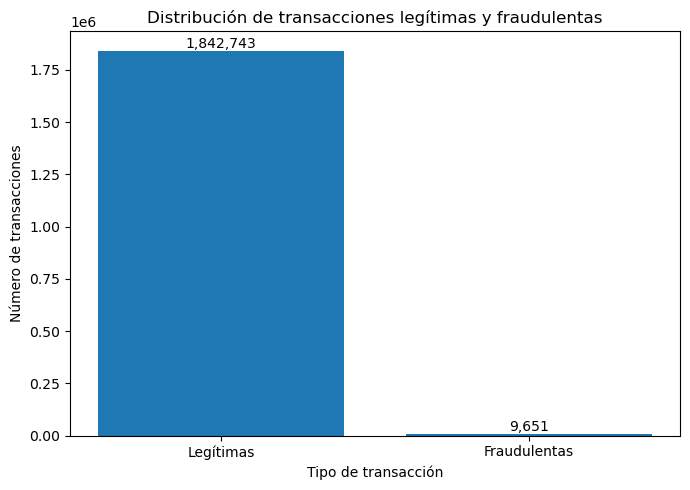

In [26]:
# Distribución de transacciones legítimas y fraudulentas

conteo = df["is_fraud"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

barras = plt.bar(
    ["Legítimas", "Fraudulentas"],
    conteo.values
)

plt.title("Distribución de transacciones legítimas y fraudulentas")
plt.ylabel("Número de transacciones")
plt.xlabel("Tipo de transacción")

# Agregar valores sobre las barras
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f"{int(altura):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

# Guardar imagen
plt.savefig("distribucion_fraude.png", dpi=300, bbox_inches="tight")

plt.show()

#### Tasa de fraude según la hora de la transacción

Se analiza la tasa de fraude para cada hora del día con el propósito de visualizar los patrones temporales identificados durante el análisis exploratorio.

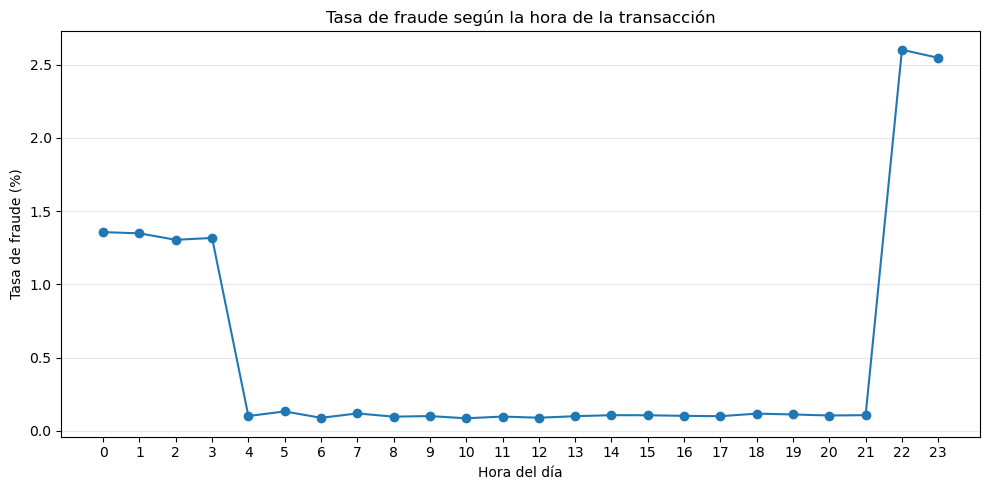

In [27]:
# Gráfico de tasa de fraude por hora

plt.figure(figsize=(10, 5))

plt.plot(
    fraude_hora.index,
    fraude_hora["tasa_fraude_%"],
    marker="o"
)

plt.title("Tasa de fraude según la hora de la transacción")
plt.xlabel("Hora del día")
plt.ylabel("Tasa de fraude (%)")

plt.xticks(range(0, 24))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Guardar imagen
plt.savefig(
    "tasa_fraude_por_hora.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Tasa de fraude según la categoría comercial

Se compara la incidencia relativa del fraude entre las diferentes categorías comerciales para identificar aquellas que presentan una mayor concentración de operaciones fraudulentas.

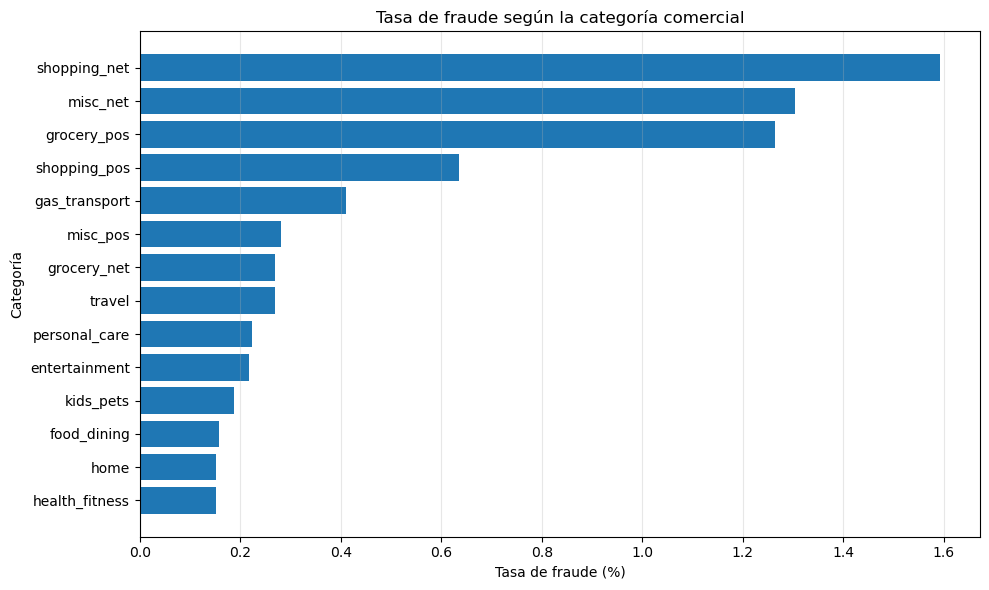

In [30]:
# Ordenar las categorías por tasa de fraude
fraude_categoria_grafico = fraude_categoria.sort_values(
    "tasa_fraude_%",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    fraude_categoria_grafico.index,
    fraude_categoria_grafico["tasa_fraude_%"]
)

plt.title("Tasa de fraude según la categoría comercial")
plt.xlabel("Tasa de fraude (%)")
plt.ylabel("Categoría")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

# Guardar imagen
plt.savefig(
    "tasa_fraude_por_categoria.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretación:**  
La visualización evidencia diferencias en la tasa de fraude según la categoría comercial. `shopping_net` presenta la mayor incidencia, con aproximadamente 1,59 %, seguida de `misc_net` con 1,30 % y `grocery_pos` con 1,27 %. Estas categorías superan ampliamente la tasa global de fraude del conjunto de datos, situada en aproximadamente 0,52 %.

Este comportamiento indica que la categoría comercial aporta información relevante para caracterizar los patrones de fraude observados. No obstante, una categoría con mayor tasa de fraude no implica que todas sus transacciones sean fraudulentas, por lo que esta variable fue utilizada en combinación con el monto y el horario en las reglas exploratorias.

#### Comparación del desempeño de las reglas

Se comparan la precisión y el recall de las tres reglas exploratorias con el propósito de visualizar el efecto de incorporar progresivamente condiciones relacionadas con monto, horario y categoría comercial.

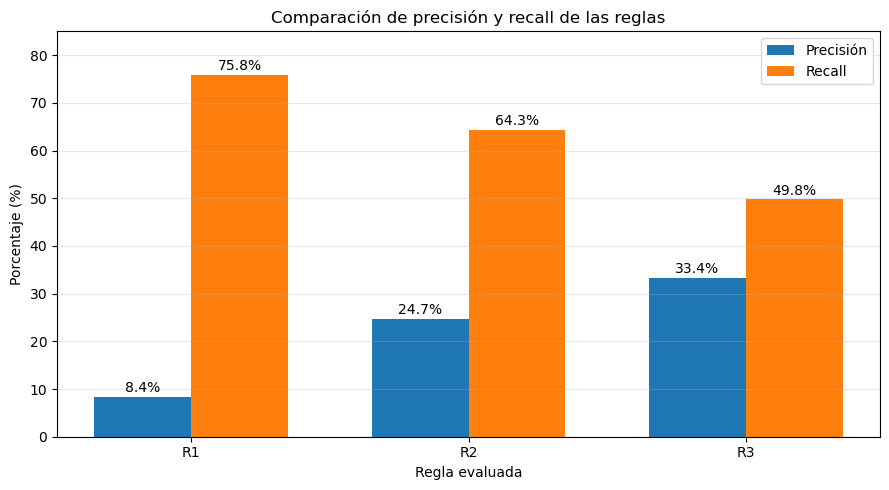

In [32]:
# Datos para comparar las reglas
nombres_reglas = ["R1", "R2", "R3"]

precision = evaluacion_reglas["Precision_%"]
recall = evaluacion_reglas["Recall_%"]

x = np.arange(len(nombres_reglas))
ancho = 0.35

plt.figure(figsize=(9, 5))

barras_precision = plt.bar(
    x - ancho/2,
    precision,
    ancho,
    label="Precisión"
)

barras_recall = plt.bar(
    x + ancho/2,
    recall,
    ancho,
    label="Recall"
)

plt.title("Comparación de precisión y recall de las reglas")
plt.xlabel("Regla evaluada")
plt.ylabel("Porcentaje (%)")
plt.xticks(x, nombres_reglas)
plt.ylim(0, 85)
plt.legend()
plt.grid(axis="y", alpha=0.3)

# Valores sobre las barras
for barras in [barras_precision, barras_recall]:
    for barra in barras:
        altura = barra.get_height()
        plt.text(
            barra.get_x() + barra.get_width()/2,
            altura + 1,
            f"{altura:.1f}%",
            ha="center"
        )

plt.tight_layout()

plt.savefig(
    "comparacion_reglas_precision_recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. Almacenamiento de datos en SQLite

Una vez finalizado el proceso de limpieza y transformación, el conjunto de datos procesado se almacena en una base de datos SQLite. Esto permite disponer de la información en una estructura persistente y realizar consultas posteriores mediante SQL.

#### Comparación del desempeño de las reglas

Se comparan la precisión y el recall de las tres reglas exploratorias con el propósito de visualizar el efecto de incorporar progresivamente condiciones relacionadas con monto, horario y categoría comercial.

In [34]:
# Crear conexión con la base de datos SQLite
conexion = sqlite3.connect("fraude_transacciones.db")

print("Conexión con SQLite creada correctamente.")

Conexión con SQLite creada correctamente.


### 3.1 Creación de la tabla de transacciones

El conjunto de datos procesado se almacena en SQLite dentro de una tabla denominada `transacciones`. La tabla contiene las variables originales consideradas relevantes y las variables temporales generadas durante el procesamiento de los datos.

In [35]:
# Guardar el DataFrame procesado en SQLite
df.to_sql(
    "transacciones",
    conexion,
    if_exists="replace",
    index=False
)

print("Datos almacenados correctamente en la tabla 'transacciones'.")

Datos almacenados correctamente en la tabla 'transacciones'.


### 3.2 Validación de la información almacenada

Para comprobar que el proceso de almacenamiento se realizó correctamente, se ejecuta una consulta SQL sobre la tabla `transacciones` para verificar el número total de registros almacenados.

In [36]:
# Consulta SQL para verificar el número de registros almacenados
consulta = """
SELECT COUNT(*) AS total_registros
FROM transacciones;
"""

resultado = pd.read_sql_query(consulta, conexion)

resultado

,total_registros
0,1852394


### 3.3 Consulta analítica mediante SQL

Una vez validado el almacenamiento de los datos, se realiza una consulta SQL para obtener la cantidad de transacciones y el monto promedio según su clasificación como operación legítima o fraudulenta. Esto permite comprobar que la base SQLite puede utilizarse posteriormente para recuperar y analizar la información procesada.

In [37]:
# Consulta SQL para analizar las transacciones por clasificación

consulta_fraude = """
SELECT
    is_fraud,
    COUNT(*) AS total_transacciones,
    ROUND(AVG(amt), 2) AS monto_promedio
FROM transacciones
GROUP BY is_fraud;
"""

resultado_fraude = pd.read_sql_query(
    consulta_fraude,
    conexion
)

resultado_fraude

,is_fraud,total_transacciones,monto_promedio
0,0,1842743,67.65
1,1,9651,530.66


In [38]:
# Cerrar la conexión con SQLite
conexion.close()

print("Conexión con SQLite cerrada correctamente.")

Conexión con SQLite cerrada correctamente.


## 4. Generación de metadata y descripción del dataset

Como parte de la documentación del proyecto, se genera un archivo de texto que resume las principales características del conjunto de datos procesado, incluyendo sus dimensiones, período analizado, distribución del fraude y descripción de las variables utilizadas.

In [39]:
# Descripción de las variables del dataset
descripcion_variables = {
    "trans_date_trans_time": "Fecha y hora de la transacción",
    "cc_num": "Número identificador de la tarjeta",
    "merchant": "Comercio donde se realizó la transacción",
    "category": "Categoría comercial de la transacción",
    "amt": "Monto de la transacción",
    "first": "Nombre del titular",
    "last": "Apellido del titular",
    "gender": "Género del titular",
    "street": "Dirección del titular",
    "city": "Ciudad del titular",
    "state": "Estado del titular",
    "zip": "Código postal",
    "lat": "Latitud asociada al titular",
    "long": "Longitud asociada al titular",
    "city_pop": "Población de la ciudad",
    "job": "Ocupación del titular",
    "dob": "Fecha de nacimiento del titular",
    "trans_num": "Identificador único de la transacción",
    "unix_time": "Fecha y hora de la transacción en formato Unix",
    "merch_lat": "Latitud del comercio",
    "merch_long": "Longitud del comercio",
    "is_fraud": "Indicador de fraude: 0 = legítima, 1 = fraudulenta",
    "year": "Año de la transacción",
    "month": "Mes de la transacción",
    "day_of_week": "Día de la semana",
    "hour": "Hora de la transacción",
    "franja_horaria": "Franja horaria generada para el análisis"
}

with open("descripcion_dataset.txt", "w", encoding="utf-8") as archivo:
    
    archivo.write("DESCRIPCIÓN DEL DATASET\n")
    archivo.write("=" * 60 + "\n\n")
    
    archivo.write(
        "Proyecto: Análisis de patrones transaccionales para el diseño "
        "y evaluación de reglas de detección de fraude en pagos electrónicos\n\n"
    )
    
    archivo.write(f"Número de registros: {len(df):,}\n")
    archivo.write(f"Número de variables procesadas: {len(df.columns)}\n")
    
    archivo.write(
        f"Período analizado: "
        f"{df['trans_date_trans_time'].min()} - "
        f"{df['trans_date_trans_time'].max()}\n\n"
    )
    
    archivo.write("DISTRIBUCIÓN DE TRANSACCIONES\n")
    archivo.write("-" * 60 + "\n")
    archivo.write(
        f"Transacciones legítimas: "
        f"{(df['is_fraud'] == 0).sum():,}\n"
    )
    archivo.write(
        f"Transacciones fraudulentas: "
        f"{(df['is_fraud'] == 1).sum():,}\n"
    )
    archivo.write(
        f"Tasa global de fraude: "
        f"{df['is_fraud'].mean() * 100:.3f}%\n\n"
    )
    
    archivo.write("DESCRIPCIÓN DE VARIABLES\n")
    archivo.write("-" * 60 + "\n")
    
    for columna in df.columns:
        descripcion = descripcion_variables.get(
            columna,
            "Variable utilizada en el análisis"
        )
        
        archivo.write(
            f"{columna} | {df[columna].dtype} | {descripcion}\n"
        )

print("Archivo 'descripcion_dataset.txt' creado correctamente.")

Archivo 'descripcion_dataset.txt' creado correctamente.


In [40]:
# Verificación del archivo de descripción generado

with open("descripcion_dataset.txt", "r", encoding="utf-8") as archivo:
    contenido = archivo.read()

print(contenido)

DESCRIPCIÓN DEL DATASET

Proyecto: Análisis de patrones transaccionales para el diseño y evaluación de reglas de detección de fraude en pagos electrónicos

Número de registros: 1,852,394
Número de variables procesadas: 27
Período analizado: 2019-01-01 00:00:18 - 2020-12-31 23:59:34

DISTRIBUCIÓN DE TRANSACCIONES
------------------------------------------------------------
Transacciones legítimas: 1,842,743
Transacciones fraudulentas: 9,651
Tasa global de fraude: 0.521%

DESCRIPCIÓN DE VARIABLES
------------------------------------------------------------
trans_date_trans_time | datetime64[ns] | Fecha y hora de la transacción
cc_num | int64 | Número identificador de la tarjeta
merchant | object | Comercio donde se realizó la transacción
category | object | Categoría comercial de la transacción
amt | float64 | Monto de la transacción
first | object | Nombre del titular
last | object | Apellido del titular
gender | object | Género del titular
street | object | Dirección del titular
city |

## 5. Exportación del conjunto de datos procesado

Como resultado del proceso de integración, limpieza y transformación, se genera una versión procesada del conjunto de datos. Este archivo conserva las variables relevantes de las fuentes originales e incorpora las variables temporales generadas durante el análisis, permitiendo mantener separados los datos originales de los datos transformados.

In [41]:
# Exportación del dataset procesado

df.to_csv(
    "fraude_transacciones_procesado.csv",
    index=False
)

print("Dataset procesado exportado correctamente.")
print("Registros:", len(df))
print("Variables:", len(df.columns))

Dataset procesado exportado correctamente.
Registros: 1852394
Variables: 27


In [42]:
# Revisión de archivos generados y sus tamaños

archivos_proyecto = []

for archivo in os.listdir():
    if os.path.isfile(archivo):
        tamano_mb = os.path.getsize(archivo) / (1024 ** 2)
        archivos_proyecto.append({
            "Archivo": archivo,
            "Tamaño_MB": round(tamano_mb, 2)
        })

tabla_archivos = pd.DataFrame(archivos_proyecto)

tabla_archivos = tabla_archivos.sort_values(
    "Tamaño_MB",
    ascending=False
).reset_index(drop=True)

tabla_archivos

,Archivo,Tamaño_MB
0,fraude_transacciones.db,519.26
1,fraude_transacciones_procesado.csv,517.88
2,fraudTrain.csv,334.97
3,fraudTest.csv,143.39
4,tasa_fraude_por_categoria.png,0.14
5,tasa_fraude_por_hora.png,0.12
6,comparacion_reglas_precision_recall.png,0.11
7,distribucion_fraude.png,0.10
8,descripcion_dataset.txt,0.00


In [44]:
print("Notebook encontrado:",
      os.path.exists("Proyecto_Fraude_Midterm.ipynb"))

Notebook encontrado: True


In [45]:
# Crear archivo .gitignore para excluir archivos pesados

contenido_gitignore = """# Datos originales
fraudTrain.csv
fraudTest.csv

# Datos procesados
fraude_transacciones_procesado.csv

# Base de datos SQLite
fraude_transacciones.db

# Archivos temporales de Jupyter
.ipynb_checkpoints/
"""

with open(".gitignore", "w", encoding="utf-8") as archivo:
    archivo.write(contenido_gitignore)

print("Archivo .gitignore creado correctamente.")

Archivo .gitignore creado correctamente.


In [46]:
# Crear archivo README.md para documentar el proyecto

contenido_readme = """# Análisis de patrones transaccionales para la detección de fraude

## Proyecto Midterm – Ciencia de Datos

### Descripción

Este proyecto analiza patrones presentes en transacciones con tarjetas de crédito
con el propósito de diseñar y evaluar reglas exploratorias para la detección de
operaciones potencialmente fraudulentas.

El proceso incluye integración, limpieza, transformación, análisis exploratorio,
visualización, almacenamiento en SQLite y evaluación de reglas mediante métricas
de clasificación.

## Fuente de datos

Se utiliza el **Credit Card Transactions Fraud Detection Dataset**, publicado
en Kaggle por Kartik Shenoy.

Dataset:
https://www.kaggle.com/datasets/kartik2112/fraud-detection

Los archivos originales utilizados son:

- `fraudTrain.csv`
- `fraudTest.csv`

Debido a su tamaño, los archivos de datos no se incluyen en este repositorio
y deben descargarse desde la fuente original.

## Dimensiones del conjunto integrado

- Transacciones analizadas: 1,852,394
- Transacciones legítimas: 1,842,743
- Transacciones fraudulentas: 9,651
- Tasa global de fraude: 0.521 %
- Período analizado: 2019–2020

## Metodología

El proyecto comprende las siguientes etapas:

1. Carga de los archivos originales.
2. Integración de los conjuntos de entrenamiento y prueba.
3. Verificación de valores nulos y registros duplicados.
4. Eliminación de variables de índice no necesarias.
5. Conversión de variables de fecha.
6. Generación de variables temporales.
7. Análisis exploratorio de patrones de fraude.
8. Diseño de reglas exploratorias de detección.
9. Evaluación mediante precisión, recall, F1-Score y tasa de falsos positivos.
10. Generación de visualizaciones.
11. Almacenamiento y consulta de datos mediante SQLite.

## Reglas exploratorias evaluadas

- **R1:** monto >= USD 200.
- **R2:** monto >= USD 200 y horario entre 22:00 y 03:59.
- **R3:** monto >= USD 200, horario entre 22:00 y 03:59 y categorías seleccionadas según la mayor tasa de fraude observada.

Las reglas muestran diferentes relaciones entre capacidad de detección y
generación de falsos positivos, por lo que su evaluación considera varias
métricas y no únicamente la cantidad de fraudes identificados.

## Principales resultados

| Regla | Precisión | Recall | F1-Score |
|---|---:|---:|---:|
| R1 | 8.38 % | 75.80 % | 15.09 % |
| R2 | 24.70 % | 64.29 % | 35.69 % |
| R3 | 33.38 % | 49.77 % | 39.96 % |

Los resultados evidencian un intercambio entre cobertura del fraude y
generación de falsos positivos. La incorporación progresiva de condiciones
aumenta la precisión de las alertas, pero reduce el porcentaje total de fraudes
detectados.

## Archivos principales

- `Proyecto_Fraude_Midterm.ipynb`: desarrollo completo del análisis.
- `descripcion_dataset.txt`: descripción y metadata de las variables.
- `distribucion_fraude.png`: distribución de transacciones.
- `tasa_fraude_por_hora.png`: comportamiento temporal del fraude.
- `tasa_fraude_por_categoria.png`: tasa de fraude por categoría comercial.
- `comparacion_reglas_precision_recall.png`: comparación de las reglas.

## Tecnologías utilizadas

- Python
- Pandas
- NumPy
- Matplotlib
- SQLite
- JupyterLab

## Nota

Las reglas desarrolladas tienen un propósito académico y exploratorio. Los
resultados corresponden exclusivamente al conjunto de datos analizado y no
deben interpretarse como reglas universales para sistemas reales de prevención
de fraude.
"""

with open("README.md", "w", encoding="utf-8") as archivo:
    archivo.write(contenido_readme)

print("Archivo README.md creado correctamente.")

Archivo README.md creado correctamente.


In [47]:
# Verificación final de archivos del proyecto

archivos_requeridos = [
    "Proyecto_Fraude_Midterm.ipynb",
    "README.md",
    ".gitignore",
    "descripcion_dataset.txt",
    "distribucion_fraude.png",
    "tasa_fraude_por_hora.png",
    "tasa_fraude_por_categoria.png",
    "comparacion_reglas_precision_recall.png"
]

print("VERIFICACIÓN DE ARCHIVOS DEL PROYECTO\n")

todos_correctos = True

for archivo in archivos_requeridos:
    existe = os.path.exists(archivo)
    
    if existe:
        print(f"OK  - {archivo}")
    else:
        print(f"FALTA - {archivo}")
        todos_correctos = False

print("\nResultado general:")

if todos_correctos:
    print("Proyecto completo y listo para preparar GitHub.")
else:
    print("Existen archivos pendientes.")

VERIFICACIÓN DE ARCHIVOS DEL PROYECTO

OK  - Proyecto_Fraude_Midterm.ipynb
OK  - README.md
OK  - .gitignore
OK  - descripcion_dataset.txt
OK  - distribucion_fraude.png
OK  - tasa_fraude_por_hora.png
OK  - tasa_fraude_por_categoria.png
OK  - comparacion_reglas_precision_recall.png

Resultado general:
Proyecto completo y listo para preparar GitHub.
